In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo
plt.style.use('ggplot')

# Definindo o nome do arquivo de dados
FILE_NAME = 'letterboxd_movies_dataset.csv'


CARREGAR DADOS

In [36]:
def load_and_clean_data(file_name):
    """Carrega o arquivo CSV e realiza a limpeza de dados essenciais."""
    try:
        df = pd.read_csv(file_name)
    except FileNotFoundError:
        print(f"ERRO: Arquivo '{file_name}' não encontrado.")
        return None

    # Limpeza e Conversão de tipos
    critical_columns = ['runtime', 'decade', 'is_english', 'title_length', 'movie_era', 'year']
    df.dropna(subset=critical_columns, inplace=True)
    df['runtime'] = df['runtime'].astype(int)
    df['decade'] = df['decade'].astype(int)
    df['year'] = df['year'].astype(int) # Garantindo que 'year' seja int para concatenação
    df['is_english'] = df['is_english'].astype(bool)

    # Remoção de duplicatas por título e ano para segurança
    df_unique = df.drop_duplicates(subset=['title', 'year'], keep='first')
    return df_unique

GRAFICOS

In [37]:
def plot_bar_chart_decade(df, title_suffix=""):
    """Cria e exibe o gráfico de barras (Requisito 2)."""
    decade_counts = df['decade'].value_counts().sort_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(x=decade_counts.index, y=decade_counts.values, palette="viridis")
    plt.title(f'Contagem de Filmes por Década {title_suffix}', fontsize=16)
    plt.xlabel('Década', fontsize=12)
    plt.ylabel('Número de Filmes', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

def plot_scatter_runtime_title_length(df, title_suffix=""):
    """Cria e exibe o gráfico de dispersão (Corrigido para legenda)."""
    df_plot = df.copy()
    df_plot['Idioma'] = df_plot['is_english'].map({True: 'Em Inglês', False: 'Outro Idioma'})

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x='runtime',
        y='title_length',
        hue='Idioma',
        data=df_plot,
        palette={'Em Inglês': 'tab:red', 'Outro Idioma': 'tab:blue'},
        s=70,
        alpha=0.7
    )
    plt.title(f'Duração (Runtime) vs. Tamanho do Título {title_suffix}', fontsize=16)
    plt.xlabel('Duração do Filme (minutos)', fontsize=12)
    plt.ylabel('Tamanho do Título (caracteres)', fontsize=12)
    plt.legend(title='Filme em Inglês')
    plt.tight_layout()
    plt.show()

def plot_box_plot_runtime_is_english(df, title_suffix=""):
    """Cria e exibe o Box Plot (Requisito 3)."""
    plt.figure(figsize=(8, 6))
    df_plot = df.copy()
    df_plot['is_english_label'] = df_plot['is_english'].map({True: 'Em Inglês', False: 'Outro Idioma'})

    sns.boxplot(x='is_english_label', y='runtime', data=df_plot, palette='Set2')
    plt.title(f'Distribuição da Duração por Idioma {title_suffix}', fontsize=16)
    plt.xlabel('Filme em Inglês', fontsize=12)
    plt.ylabel('Duração do Filme (minutos)', fontsize=12)
    plt.tight_layout()
    plt.show()

FILTRAGEM

In [38]:
def convert_df_to_dict(df):
    """
    Converte o DataFrame para um Dicionário de Dicionários, utilizando a coluna
    'title_year' como identificador único para evitar o ValueError.
    """
    # 1. Cria a coluna 'title_year' (título + ano) para garantir a unicidade.
    df['title_year'] = df['title'] + ' (' + df['year'].astype(str) + ')'

    # 2. LINHA EXATA SOLICITADA PARA CONVERSÃO, usando a coluna única.
    data_dict = df.set_index('title_year').to_dict(orient='index')

    return data_dict

def filter_data_structure(data_dict):
    """Filtra o Dicionário usando Python puro (sem Pandas)."""
    filtered_dict = {}
    for key, movie in data_dict.items():
        is_contemporary = (movie.get('movie_era') == 'Contemporary')
        is_long = (movie.get('runtime', 0) > 120)

        if is_contemporary and is_long:
            filtered_dict[key] = movie
    return filtered_dict

def convert_dict_to_df(data_dict):
    """Converte o Dicionário de Dicionários de volta para um DataFrame."""
    if not data_dict:
        return pd.DataFrame()
    return pd.DataFrame.from_dict(data_dict, orient='index')

print("--- DEFINIÇÕES CONCLUÍDAS. INICIANDO EXECUÇÃO ---")

--- DEFINIÇÕES CONCLUÍDAS. INICIANDO EXECUÇÃO ---


EXECUCAO PRINCIPAL


--- ETAPA 2: CARREGAMENTO E AED NO DATASET ORIGINAL ---
Dataset 'letterboxd_movies_dataset.csv' carregado e limpo. Total de filmes: 16210

[REQUISITO 2] Gráfico de Barras: Contagem por Década (Original)


/tmp/ipython-input-2623320002.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_counts.index, y=decade_counts.values, palette="viridis")


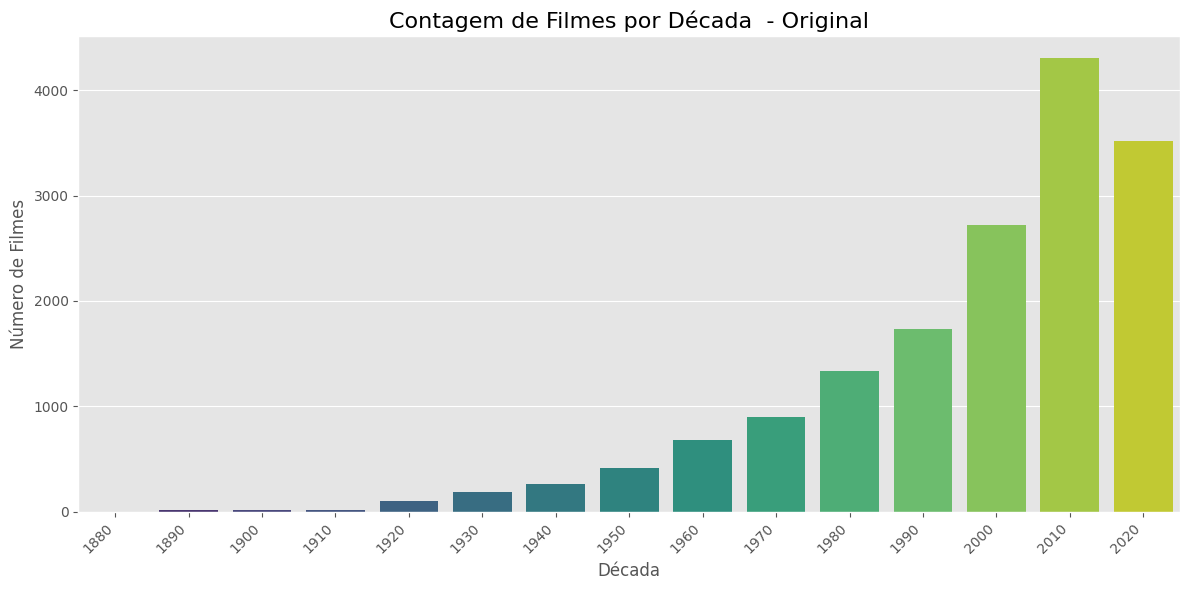


[REQUISITO 3] Scatter Plot: Duração vs. Título (Original)


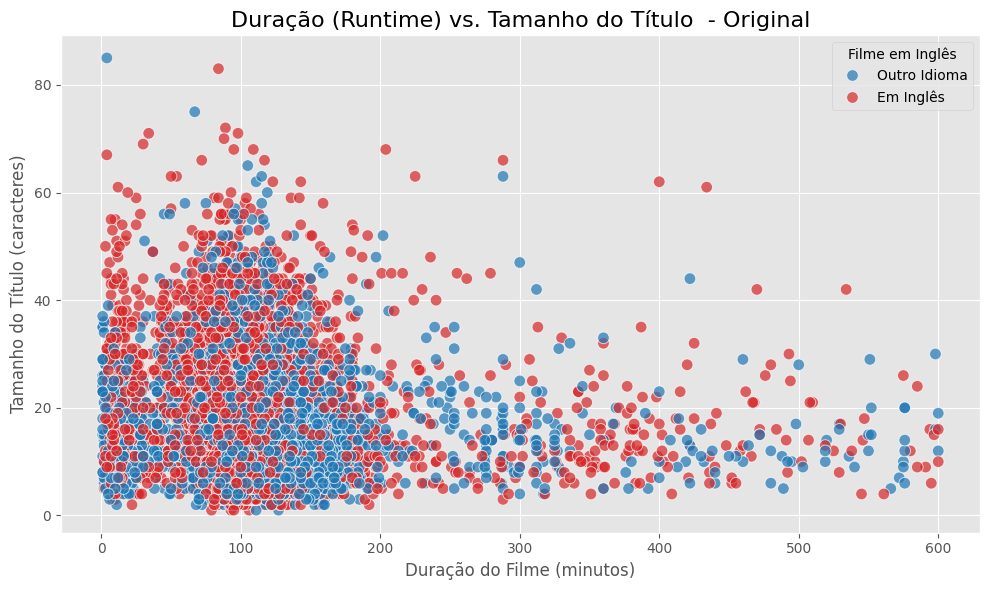


[REQUISITO 3] Box Plot: Duração por Idioma (Original)


/tmp/ipython-input-2623320002.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_english_label', y='runtime', data=df_plot, palette='Set2')


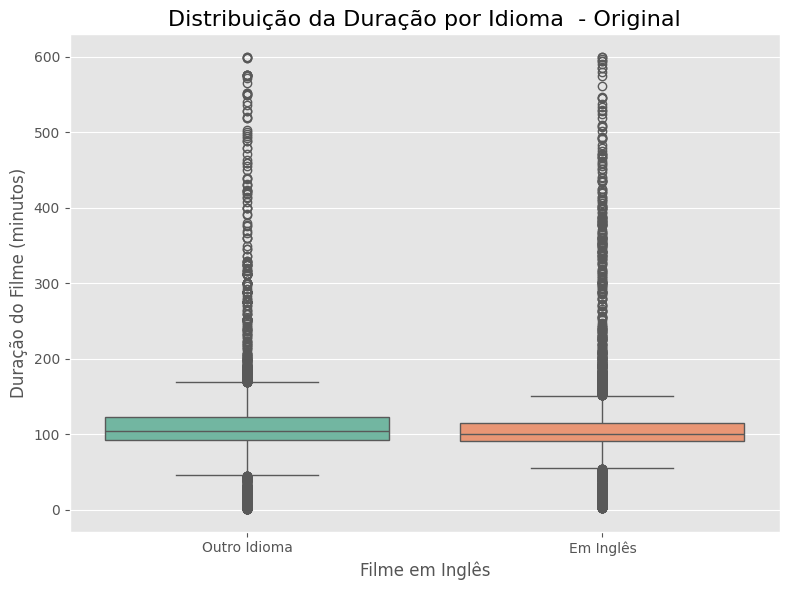


--- ETAPA 3: FILTRAGEM EM PYTHON PURO (REQUISITO 5) ---
Filtros: Era 'Contemporary' E Duração > 120 min.
Filtragem concluída. Novo dataset com 1758 filmes.

[REQUISITO 5] Gráfico de Barras: Contagem por Década (Filtrado)


/tmp/ipython-input-2623320002.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_counts.index, y=decade_counts.values, palette="viridis")


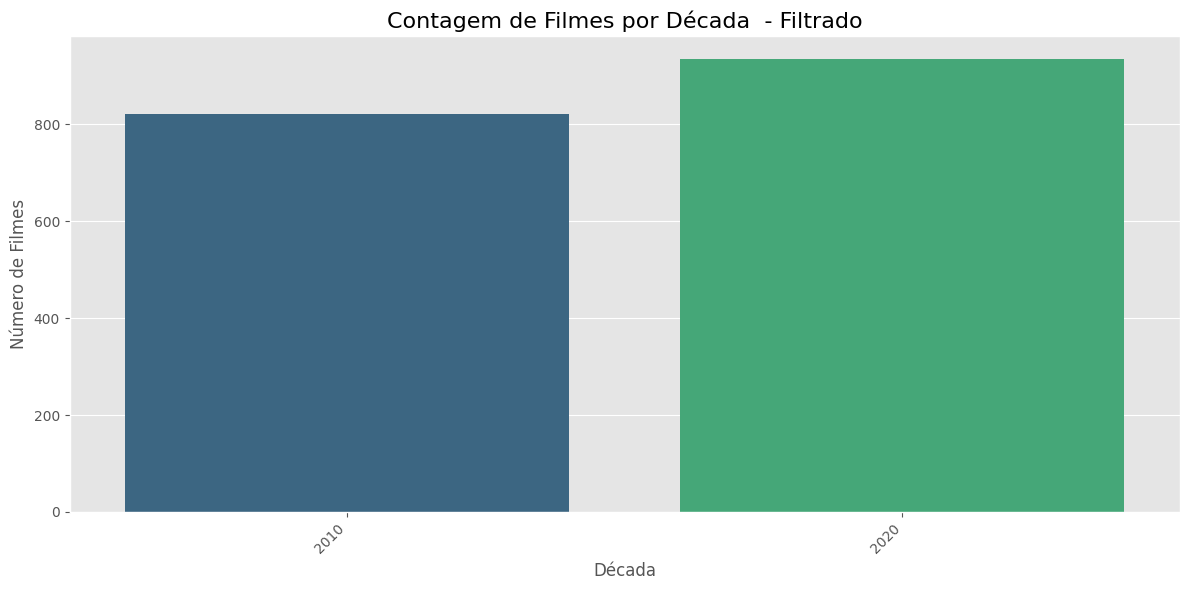


[REQUISITO 5] Scatter Plot: Duração vs. Título (Filtrado)


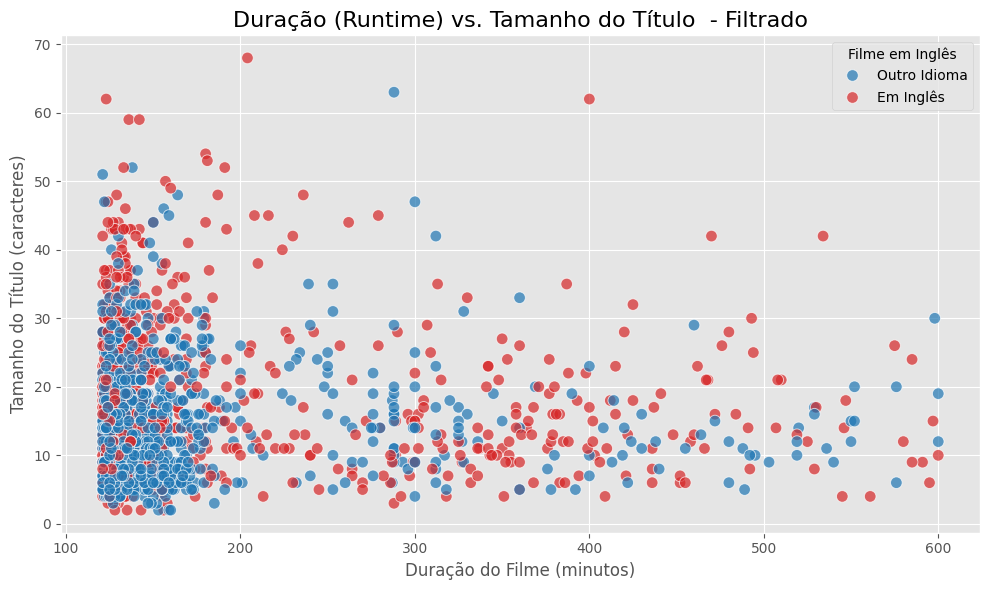


[REQUISITO 5] Box Plot: Duração por Idioma (Filtrado)


/tmp/ipython-input-2623320002.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_english_label', y='runtime', data=df_plot, palette='Set2')


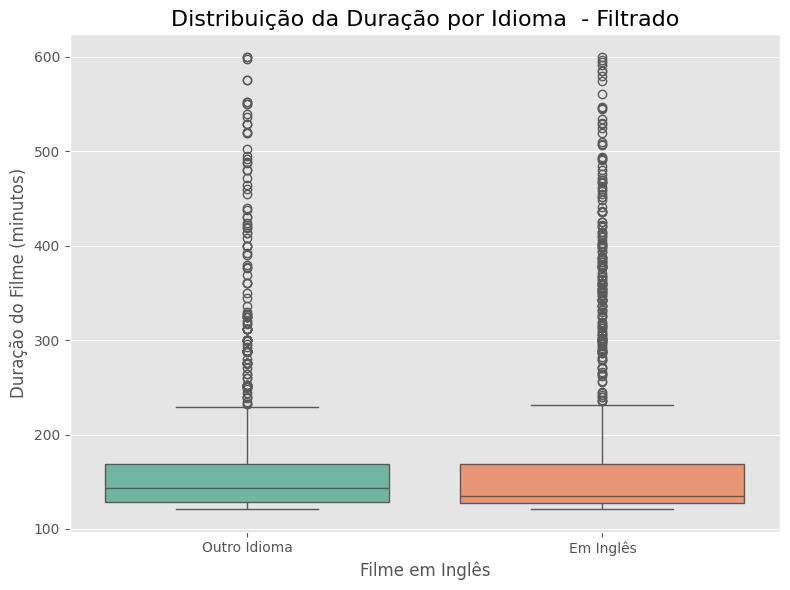

In [39]:
print("\n--- ETAPA 2: CARREGAMENTO E AED NO DATASET ORIGINAL ---")
df_original = load_and_clean_data(FILE_NAME)

if df_original is not None and not df_original.empty:
    print(f"Dataset '{FILE_NAME}' carregado e limpo. Total de filmes: {len(df_original)}")

    print("\n[REQUISITO 2] Gráfico de Barras: Contagem por Década (Original)")
    plot_bar_chart_decade(df_original, title_suffix=" - Original")

    print("\n[REQUISITO 3] Scatter Plot: Duração vs. Título (Original)")
    plot_scatter_runtime_title_length(df_original, title_suffix=" - Original")

    print("\n[REQUISITO 3] Box Plot: Duração por Idioma (Original)")
    plot_box_plot_runtime_is_english(df_original, title_suffix=" - Original")

    # 2. FILTRAGEM E AED PÓS-FILTRO (REQUISITO 5)
    print("\n--- ETAPA 3: FILTRAGEM EM PYTHON PURO (REQUISITO 5) ---")
    print("Filtros: Era 'Contemporary' E Duração > 120 min.")

    dict_data = convert_df_to_dict(df_original.copy())
    filtered_dict = filter_data_structure(dict_data)
    df_filtered = convert_dict_to_df(filtered_dict)

    if not df_filtered.empty:
        print(f"Filtragem concluída. Novo dataset com {len(df_filtered)} filmes.")

        print("\n[REQUISITO 5] Gráfico de Barras: Contagem por Década (Filtrado)")
        plot_bar_chart_decade(df_filtered, title_suffix=" - Filtrado")

        print("\n[REQUISITO 5] Scatter Plot: Duração vs. Título (Filtrado)")
        plot_scatter_runtime_title_length(df_filtered, title_suffix=" - Filtrado")

        print("\n[REQUISITO 5] Box Plot: Duração por Idioma (Filtrado)")
        plot_box_plot_runtime_is_english(df_filtered, title_suffix=" - Filtrado")
    else:
        print("O dataset filtrado não possui filmes que atendam aos critérios.")